In [1]:
import os
import pickle
from time import perf_counter
from functools import partial

import numpy as np
import tensorflow as tf
from bayesflow.amortizers import AmortizedPosterior
from bayesflow.networks import InvertibleNetwork
from bayesflow.helper_networks import MultiConv1D
from bayesflow.simulation import GenerativeModel, Prior, Simulator
from bayesflow.trainers import Trainer
from bayesflow import default_settings as defaults
from tensorflow.keras.layers import Dense, GRU, LSTM
from tensorflow.keras.models import Sequential

/Users/jonas.arruda/miniconda/envs/SamplingBias/lib/python3.10/site-packages/bayesflow/trainers.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
def prior(batch_size: int) -> np.ndarray:
    param_batch = np.zeros((batch_size, 12))
    # alpha
    param_batch[:, 0] = np.random.uniform(0, 0.1, batch_size)
    # beta
    param_batch[:, 1] = np.random.uniform(0, 10, batch_size)
    # delta
    param_batch[:, 2] = np.random.uniform(-3, 3, batch_size)
    # mu_inf
    param_batch[:, 3:8] = np.exp(np.random.normal(0, 1, (batch_size, 5)))
    # mu_susc
    param_batch[:, 8:10] = np.exp(np.random.normal(0, 1, (batch_size, 2)))
    # mu_protect
    param_batch[:, 10:] = np.exp(np.random.normal(0, 1, (batch_size, 2)))
    return param_batch

In [3]:
# check if GPU is available
n_gpus = len(tf.config.experimental.list_physical_devices('GPU'))
print("Num GPUs Available: ", n_gpus)

if n_gpus > 0:
    param_names = ['alpha', 'beta', 'delta',
                   'mu_inf_SC', 'mu_inf_SA', 'mu_inf_AI', 'mu_inf_AC', 'mu_inf_AA',
                   'mu_susc_C', 'mu_susc_A',
                   'mu_protect_acq', 'mu_protect_transm']
    n_households = 128
    length_time_series = 8


    def simulator(params: np.ndarray):
        # gpu cannot handle R modules for some reason
        raise NotImplementedError('simulator function not implemented')

else:
    from Simulator.simulator import simulator, param_names

    _sim = simulator(prior(1).flatten())
    n_households = _sim.shape[0]
    length_time_series = _sim.shape[1]
n_params = len(param_names)

Num GPUs Available:  0


Attaching package: ‘dplyr’



    filter, lag



    intersect, setdiff, setequal, union


Attaching package: ‘actuar’



    sd, var



    cm




In [4]:
np.random.seed(42)
_prior_draws = prior(1000)
assert _prior_draws.shape == (1000, n_params)
prior_mean = _prior_draws.mean(axis=0)
prior_std = _prior_draws.std(axis=0)
print(prior_mean, prior_std)

[0.04902566 5.07017305 0.01443436 1.68006372 1.71245816 1.66438047
 1.55648132 1.55568159 1.72394693 1.64807425 1.53430526 1.55909314] [0.02919913 2.92043762 1.74317293 2.52451191 2.58105783 2.16778593
 1.9663979  1.82013528 2.34377529 1.93896357 1.84470246 1.80754526]


In [5]:
bayesflow_prior = Prior(batch_prior_fun=prior,
                        param_names=param_names)
bayes_simulator = Simulator(simulator_fun=simulator)
generative_model = GenerativeModel(prior=bayesflow_prior, simulator=bayes_simulator,
                                   skip_test=True,
                                   name="Pedcov Household Sampling")

In [6]:
bayes_simulator_random = Simulator(simulator_fun=partial(simulator, selection_procedure='random'))
generative_model_rand = GenerativeModel(prior=bayesflow_prior, simulator=bayes_simulator_random,
                                        skip_test=True,
                                        name="Random Household Sampling")

In [7]:
def configurator(forward_dict: dict) -> dict:
    out_dict = {}

    # Extract data (already normalized)
    x = forward_dict["sim_data"].astype(np.float32)    
    #x[:, :, -1, 1:] = 1  # todo: change to 1, end of follow-up
    idx_keep = np.all(np.isfinite(x), axis=(1, 2, 3))
    out_dict['summary_conditions'] = x[idx_keep]
    
    # if simulations contains nan
    if not np.all(idx_keep):
        print(f'Invalid value(s) encountered...removing {idx_keep.size - np.sum(idx_keep)} entry(ies) from batch')
    
    # Extract params
    if 'parameters' in forward_dict.keys():
        forward_dict["prior_draws"] = forward_dict["parameters"]
    if 'prior_draws' in forward_dict.keys():
        params = forward_dict["prior_draws"].astype(np.float32)
        params = (params - prior_mean) / prior_std
        out_dict['parameters'] = params[idx_keep]
    return out_dict

In [8]:
class GroupSummaryNetwork(tf.keras.Model):
    
    def __init__(
        self, summary_dim, rnn_units=128, use_lstm=False, 
            conv_settings=None, num_conv_layers=0, pool_with_sum=False, **kwargs
    ):
        super().__init__(**kwargs)
        if conv_settings is None:
            conv_settings = defaults.DEFAULT_SETTING_MULTI_CONV

        self.conv = Sequential([MultiConv1D(conv_settings) for _ in range(num_conv_layers)])

        self.rnn = LSTM(rnn_units) if use_lstm else GRU(rnn_units)
        self.out_layer = Dense(summary_dim, activation="linear")
        self.summary_dim = summary_dim
        self.pool_with_sum = pool_with_sum
        
    def call(self, x, **kwargs):
        """Performs a forward pass through the network by first passing `x` through the same rnn network for
        each household and then pooling the outputs across households.

        Parameters
        ----------
        x : tf.Tensor
            Input of shape (batch_size, n_groups, n_time_steps, n_features)

        Returns
        -------
        out : tf.Tensor
            Output of shape (batch_size, summary_dim)
        """
        # iterate over groups
        out_list = []  # list to store outputs of LSTM for each group
        for i in range(x.shape[1]):
            out = self.conv(x[:, i], **kwargs)  # (batch_size, n_time_steps, n_features)
            out = self.rnn(out, **kwargs)  # (batch_size, lstm_units)
            out_list.append(out)
        # one could apply a time-resolved equivariant layer here and then pool
        if self.pool_with_sum:
            out = tf.reduce_sum(out_list, axis=0)  # (batch_size, lstm_units)
        else:
            # max pooling over groups
            out = tf.reduce_max(out_list, axis=0)  # (batch_size, lstm_units)
        # apply dense layer
        out = self.out_layer(out, **kwargs)  # (batch_size, summary_dim)
        return out

In [9]:
# settings
net_id = 5
if net_id == 0:
    name = 'amortizer-sampling-bias-1'
    num_conv_layers = 0
    use_lstm = False
    num_coupling_layers = 6
    coupling_design = 'spline'
    coupling_settings = {
        "num_dense": 2,
        "dense_args": dict(
            activation='relu',
            kernel_regularizer=tf.keras.regularizers.l2(1e-4)
        )
    }
    use_cosine_decay = True
    use_early_stopping = True
    pool_with_sum = False
elif net_id == 1:
    name = 'amortizer-sampling-bias-2'
    num_conv_layers = 0
    use_lstm = True
    num_coupling_layers = 7
    coupling_design = 'spline'
    coupling_settings = {
        "num_dense": 3,
        "dense_args": dict(
            activation='relu',
            kernel_regularizer=tf.keras.regularizers.l2(1e-4)
        ),
        "dropout_prob": 0.1,
    }
    use_cosine_decay = True
    use_early_stopping = True
    pool_with_sum = False
elif net_id == 2:
    name = 'amortizer-sampling-bias-2-spec'
    num_conv_layers = 0
    use_lstm = True
    num_coupling_layers = 7
    coupling_design = 'spline'
    coupling_settings = {
        "num_dense": 3,
        "dense_args": dict(
            activation='relu',
            kernel_regularizer=tf.keras.regularizers.l2(1e-4)
        ),
        "dropout_prob": 0.1,
        "spec_norm": True
    }
    use_cosine_decay = True
    use_early_stopping = True
    pool_with_sum = False
elif net_id == 3:
    name = 'amortizer-sampling-bias-2-spec-opt'
    num_conv_layers = 0
    use_lstm = True
    num_coupling_layers = 7
    coupling_design = 'spline'
    coupling_settings = {
        "num_dense": 3,
        "dense_args": dict(
            activation='relu',
            kernel_regularizer=tf.keras.regularizers.l2(1e-4)
        ),
        "dropout_prob": 0.2,
        "spec_norm": True
    }
    use_cosine_decay = False
    use_early_stopping = True
    pool_with_sum = False
elif net_id == 4:
    name = 'amortizer-sampling-bias-3-spec'
    num_conv_layers = 0
    use_lstm = True
    num_coupling_layers = 7
    coupling_design = 'spline'
    coupling_settings = {
        "num_dense": 3,
        "dense_args": dict(
            activation='relu',
            kernel_regularizer=tf.keras.regularizers.l2(1e-4)
        ),
        "dropout_prob": 0.1,
        "spec_norm": True
    }
    use_cosine_decay = True
    use_early_stopping = False
    pool_with_sum = False
elif net_id == 5:
    name = 'amortizer-sampling-bias-4-spec-bins-opt'
    num_conv_layers = 0
    use_lstm = True
    num_coupling_layers = 7
    coupling_design = 'spline'
    coupling_settings = {
        "num_dense": 3,
        "dense_args": dict(
            activation='relu',
            kernel_regularizer=tf.keras.regularizers.l2(1e-4)
        ),
        "dropout_prob": 0.2,
        "spec_norm": True,
        "bins": 32
    }
    use_cosine_decay = False
    use_early_stopping = True
    pool_with_sum = False
elif net_id == 6:
    name = 'amortizer-sampling-bias-4-spec-bins-opt-conv'
    num_conv_layers = 2
    use_lstm = True
    num_coupling_layers = 7
    coupling_design = 'spline'
    coupling_settings = {
        "num_dense": 3,
        "dense_args": dict(
            activation='relu',
            kernel_regularizer=tf.keras.regularizers.l2(1e-4)
        ),
        "dropout_prob": 0.2,
        "spec_norm": True,
        "bins": 32
    }
    use_cosine_decay = False
    use_early_stopping = True
    pool_with_sum = False
elif net_id == 7:
    name = 'amortizer-sampling-bias-5-spec-bins-conv'
    num_conv_layers = 2
    use_lstm = True
    num_coupling_layers = 9
    coupling_design = 'spline'
    coupling_settings = {
        "num_dense": 4,
        "dense_args": dict(
            activation='relu',
            kernel_regularizer=tf.keras.regularizers.l2(1e-4)
        ),
        "dropout_prob": 0.2,
        "spec_norm": True,
        "bins": 32,
        "act_norm_init": ((prior(batch_size=64) - prior_mean) / prior_std).astype(np.float32)
    }
    use_cosine_decay = True
    use_early_stopping = True
    pool_with_sum = False
elif net_id == 8:
    name = 'amortizer-sampling-bias-6-sum'
    num_conv_layers = 2
    use_lstm = True
    num_coupling_layers = 9
    coupling_design = 'affine'
    coupling_settings = {
        "num_dense": 4,
        "dense_args": dict(
            activation='relu',
            kernel_regularizer=tf.keras.regularizers.l2(1e-4)
        ),
        "dropout_prob": 0.2,
        "spec_norm": True,
        "act_norm_init": ((prior(batch_size=64) - prior_mean) / prior_std).astype(np.float32)
    }
    use_cosine_decay = True
    use_early_stopping = True
    pool_with_sum = True
elif net_id == 9:
    name = 'amortizer-sampling-bias-6-sum-end-of-followup'
    num_conv_layers = 2
    use_lstm = True
    num_coupling_layers = 9
    coupling_design = 'affine'
    coupling_settings = {
        "num_dense": 4,
        "dense_args": dict(
            activation='relu',
            kernel_regularizer=tf.keras.regularizers.l2(1e-4)
        ),
        "dropout_prob": 0.2,
        "spec_norm": True,
        "act_norm_init": ((prior(batch_size=64) - prior_mean) / prior_std).astype(np.float32)
    }
    use_cosine_decay = True
    use_early_stopping = True
    pool_with_sum = True
    # changed data, end of follow-up is 1 instead of 0
else:
    raise ValueError('Invalid network id')

In [10]:
power_k_hidden_units = int(np.ceil(np.log2(length_time_series)))
summary_net = GroupSummaryNetwork(summary_dim=n_params*2,
                                  rnn_units=2**power_k_hidden_units,
                                  num_conv_layers=num_conv_layers,
                                  use_lstm=use_lstm,
                                  pool_with_sum=pool_with_sum)
inference_net = InvertibleNetwork(num_params=n_params,
                                  num_coupling_layers=num_coupling_layers,
                                  coupling_design='spline',
                                  coupling_settings=coupling_settings)

In [11]:
amortizer = AmortizedPosterior(inference_net=inference_net, summary_net=summary_net)
checkpoint_path = 'amortizer/' + name
print(checkpoint_path)

# build the trainer with networks and generative model
trainer = Trainer(amortizer=amortizer,
                  configurator=configurator,
                  generative_model=generative_model,
                  checkpoint_path=checkpoint_path,
                  skip_checks=True,
                  max_to_keep=1)

INFO:root:Loaded loss history from amortizer/amortizer-sampling-bias-4-spec-bins-opt/history_1000.pkl.
INFO:root:Networks loaded from amortizer/amortizer-sampling-bias-4-spec-bins-opt/ckpt-1000


amortizer/amortizer-sampling-bias-4-spec-bins-opt


In [12]:
presimulate = False
train_network = False

batch_size = 64
iterations_per_epoch = 10
max_epochs = 1000
job_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0))

np.random.seed(42)
# check if the data exists
if os.path.exists('valid_data.pickle'):
    with open('valid_data.pickle', 'rb') as f:
        valid_data = pickle.load(f)
else:
    print('generating validation data')
    valid_data = generative_model(128)

    # save the data
    with open('valid_data.pickle', 'wb') as f:
        pickle.dump(valid_data, f)

np.random.seed(42)  # same seed as before, so prior samples are the same
# check if the data exists
if os.path.exists('valid_data_rand.pickle'):
    with open('valid_data_rand.pickle', 'rb') as f:
        valid_data_rand = pickle.load(f)
else:
    print('generating validation data random')
    valid_data_rand = generative_model_rand(128)

    # save the data
    with open('valid_data_rand.pickle', 'wb') as f:
        pickle.dump(valid_data_rand, f)

In [13]:
if presimulate:
    start_time = perf_counter()
    generative_model.presimulate_and_save(batch_size=64, 
                                          folder_path='presimulations',
                                          iterations_per_epoch=iterations_per_epoch,
                                          epochs=1,
                                          extend_from=job_id,
                                          disable_user_input=True)
    end_time = perf_counter()
    print(f'simulation time: {(end_time-start_time)/60} minutes')

In [14]:
if train_network:
    # simulation done before, start training now
    start_time = perf_counter()
    if use_cosine_decay:
        trainer._setup_optimizer(optimizer=None,
                                 epochs=max_epochs,
                                 iterations_per_epoch=iterations_per_epoch)
        optimizer = trainer.optimizer
    else:
         # without cosine decay
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005, global_clipnorm=1.0) 

    history = trainer.train_from_presimulation(presimulation_path='presimulations',
                                               optimizer=optimizer,
                                               max_epochs=max_epochs,
                                               early_stopping=use_early_stopping,
                                               early_stopping_args={'patience': 15},  # todo: 15
                                               validation_sims=valid_data)

    end_time = perf_counter()
    print(f'training time: {(end_time-start_time)/60} minutes')
else:
    trainer.load_pretrained_network()
    history = trainer.loss_history.get_plottable()

# Diagnostic

In [15]:
import bayesflow as bf
from tarp import get_tarp_coverage
from matplotlib import pyplot as plt

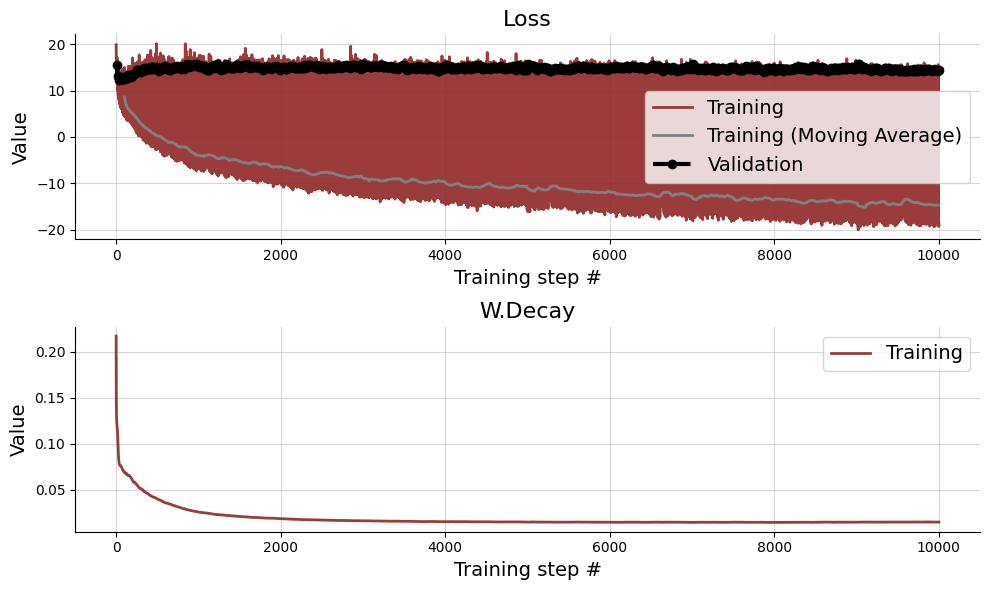

In [16]:
bf.diagnostics.plot_losses(history['train_losses'], history['val_losses'], 
                           moving_average=True, fig_size=(10, 6));

In [17]:
test_sims = trainer.configurator(valid_data)

In [18]:
posterior_samples = amortizer.sample(test_sims, n_samples=100)
posterior_samples = posterior_samples * prior_std + prior_mean
prior_draws = test_sims["parameters"] * prior_std + prior_mean

INFO:root:The ratio of simulations / posterior draws should be > 20 for reliable variance reduction, but your ratio is 1.                    Confidence intervals might be unreliable!


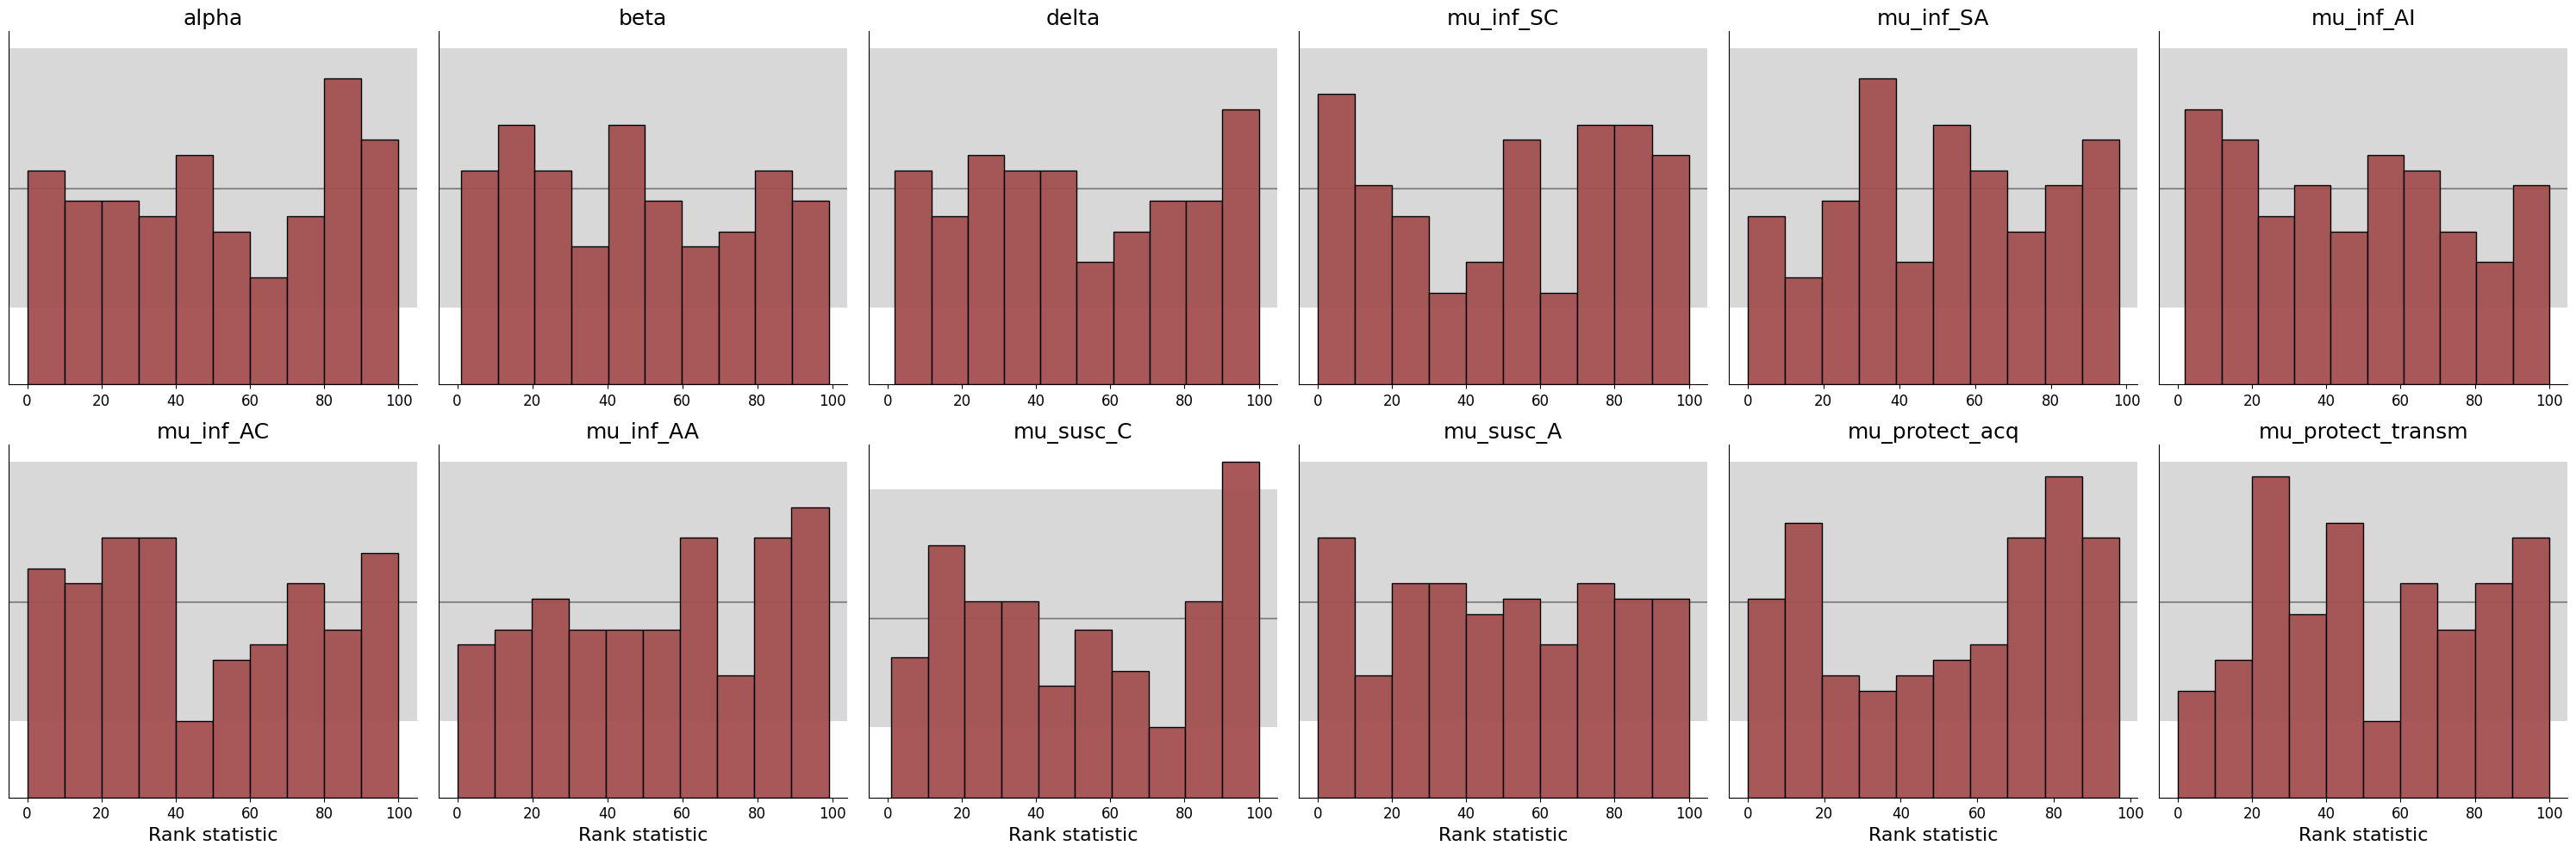

In [19]:
bf.diagnostics.plot_sbc_histograms(posterior_samples, prior_draws, num_bins=10, param_names=param_names);

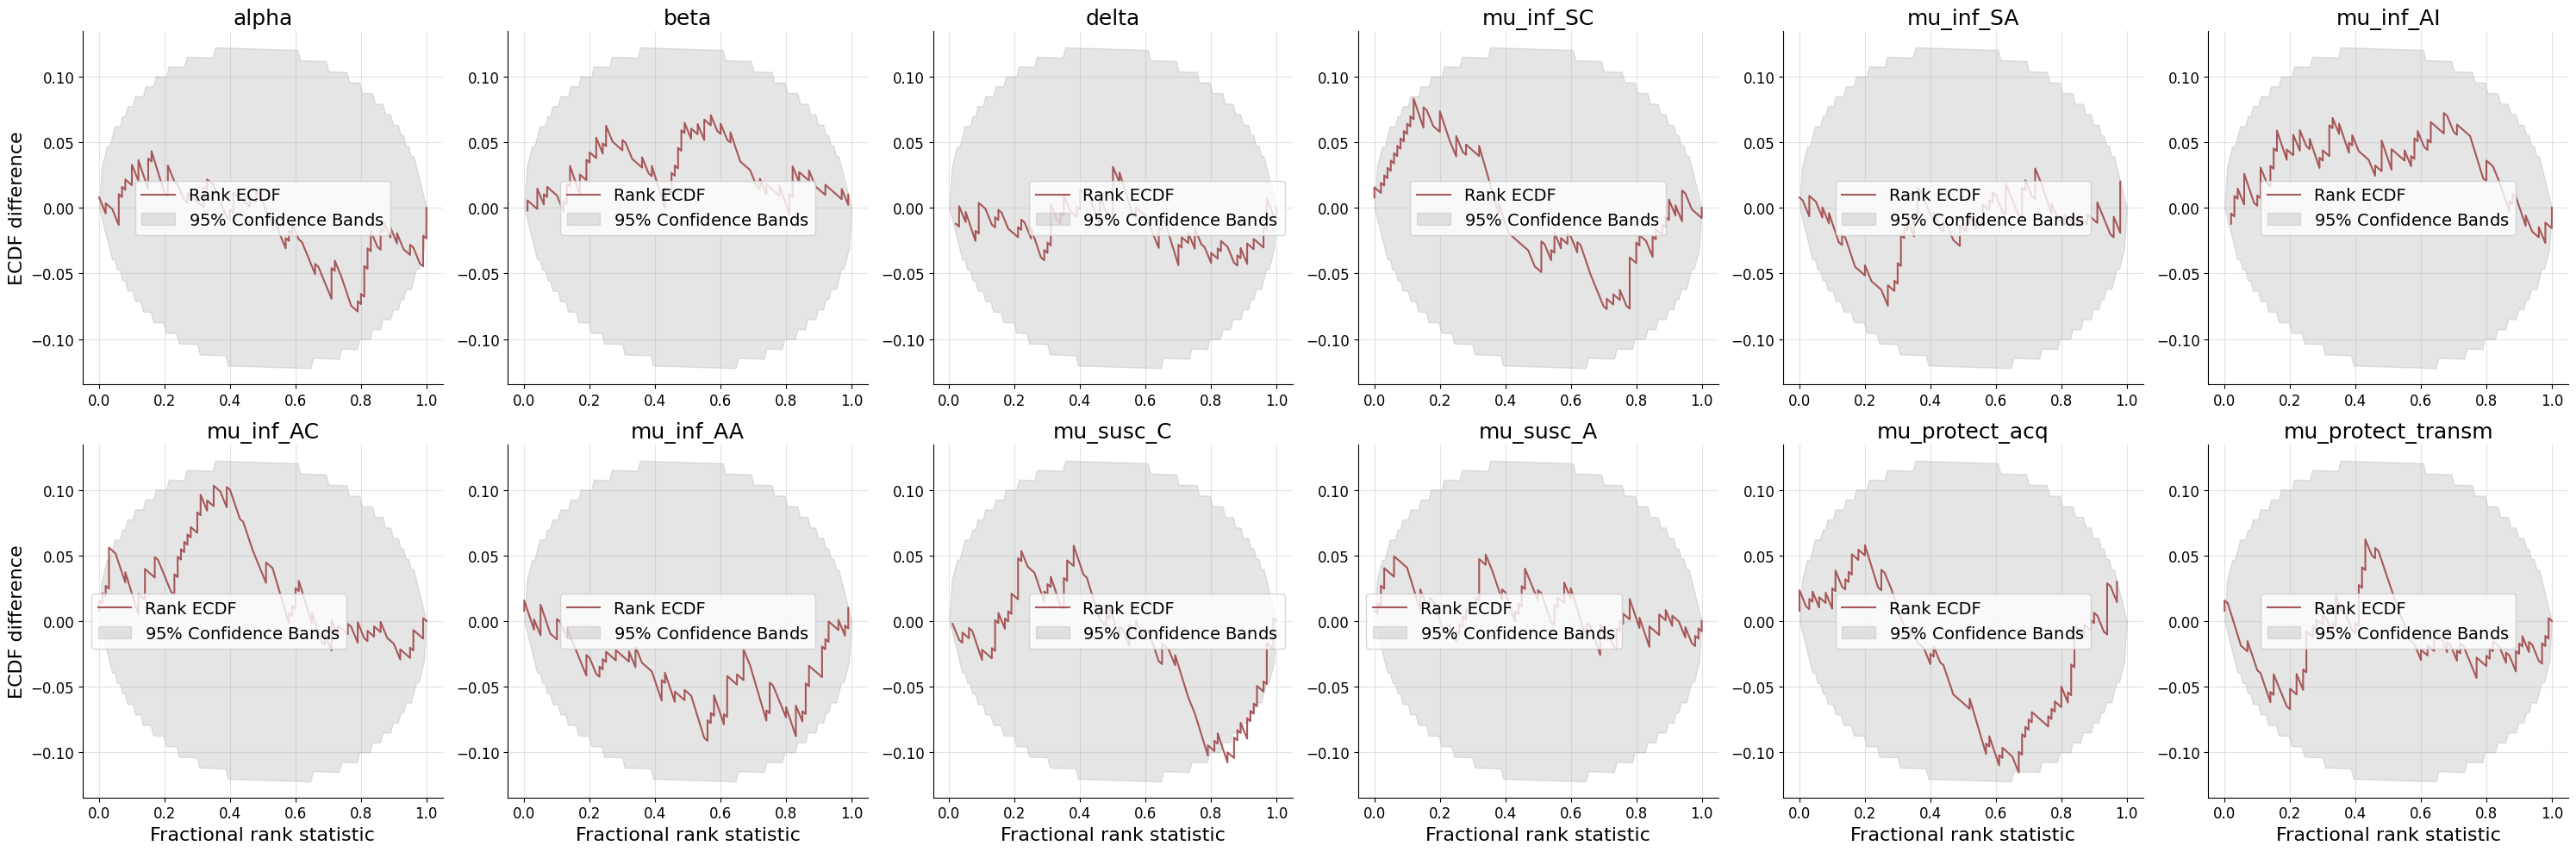

In [20]:
bf.diagnostics.plot_sbc_ecdf(posterior_samples, prior_draws, difference=True, param_names=param_names);

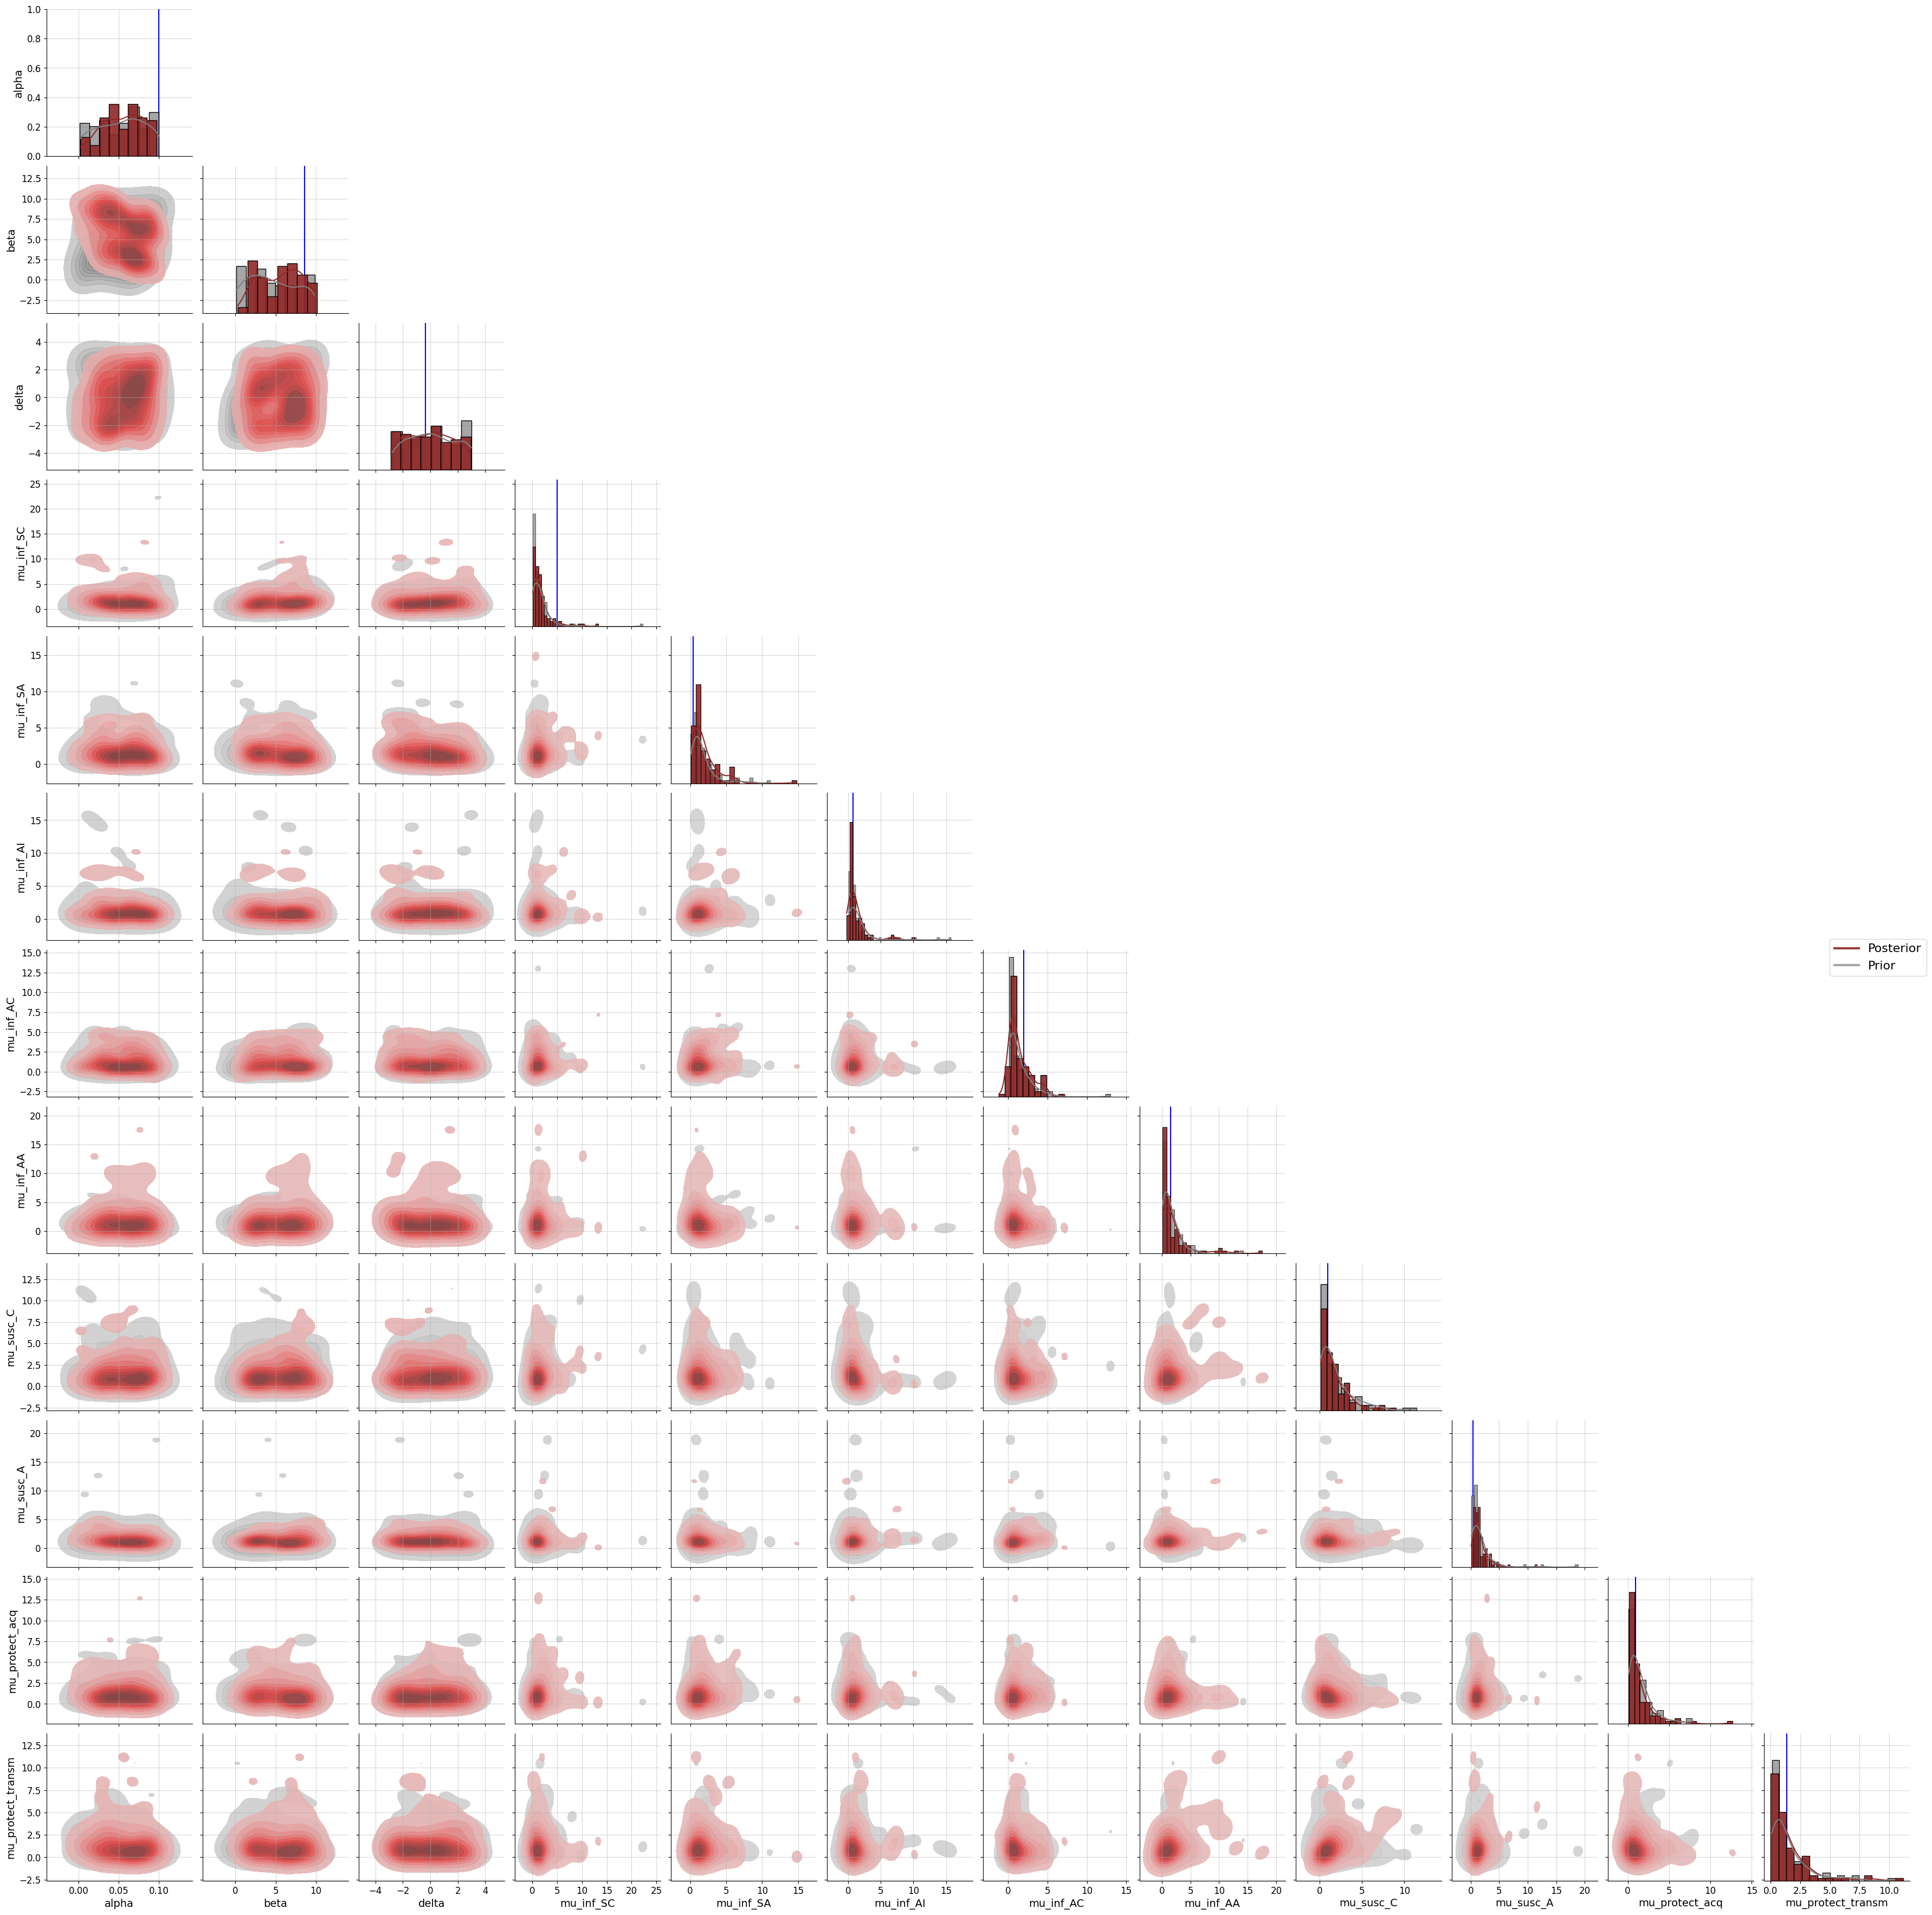

In [21]:
posterior_samples = amortizer.sample(test_sims, n_samples=100)
posterior_samples = posterior_samples * prior_std + prior_mean
sample_id = 0
fig = bf.diagnostics.plot_posterior_2d(posterior_draws=posterior_samples[sample_id],
                                       prior_draws=prior_draws[:posterior_samples.shape[1]], param_names=param_names)
# from figure get axis
ax = fig.get_axes()
for i, a in enumerate(ax):
    # plot only on the diagonal
    if i == i // len(param_names) * (len(param_names) + 1):
        a.axvline(prior_draws[sample_id][i // len(param_names)], color='b', label='True parameter')

In [22]:
# remove nan
remove = np.any(np.isnan(posterior_samples), axis=(1, 2))
if np.any(remove):
    print(f"Removing {np.sum(remove)} entries with nan")

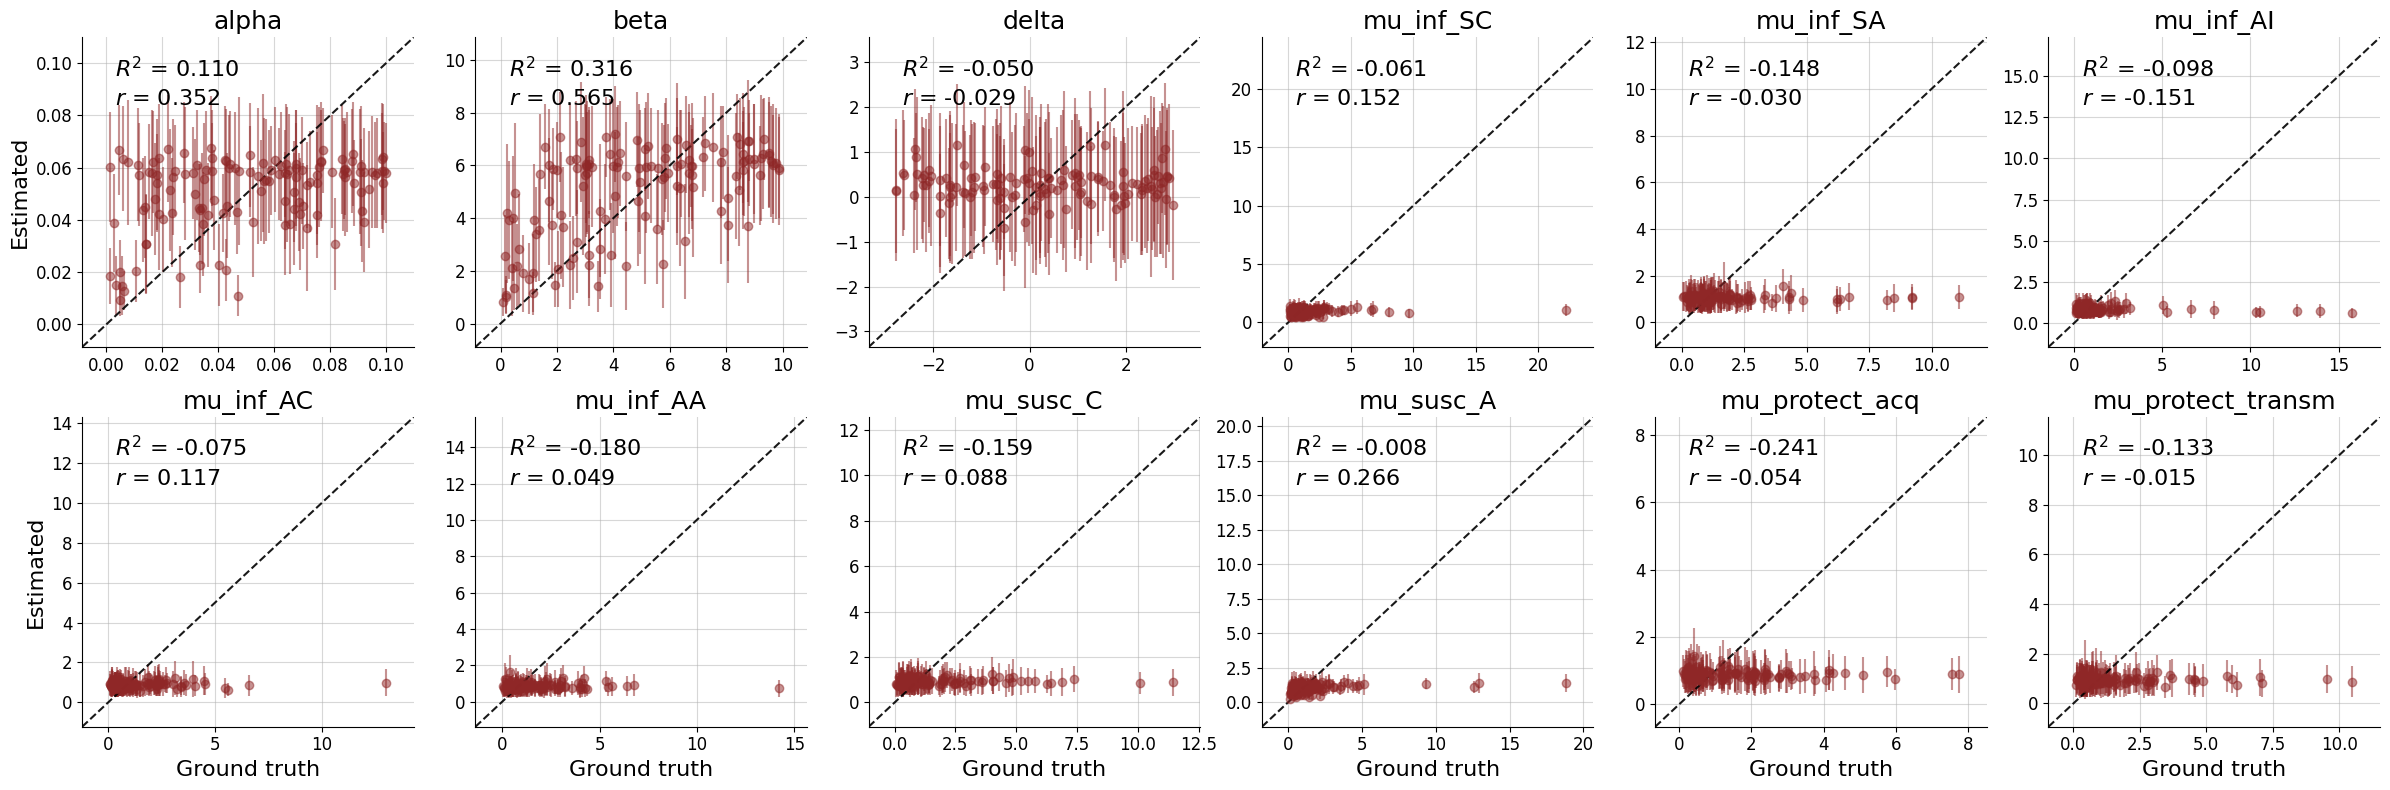

In [23]:
bf.diagnostics.plot_recovery(posterior_samples[~remove], prior_draws[~remove], param_names=param_names);

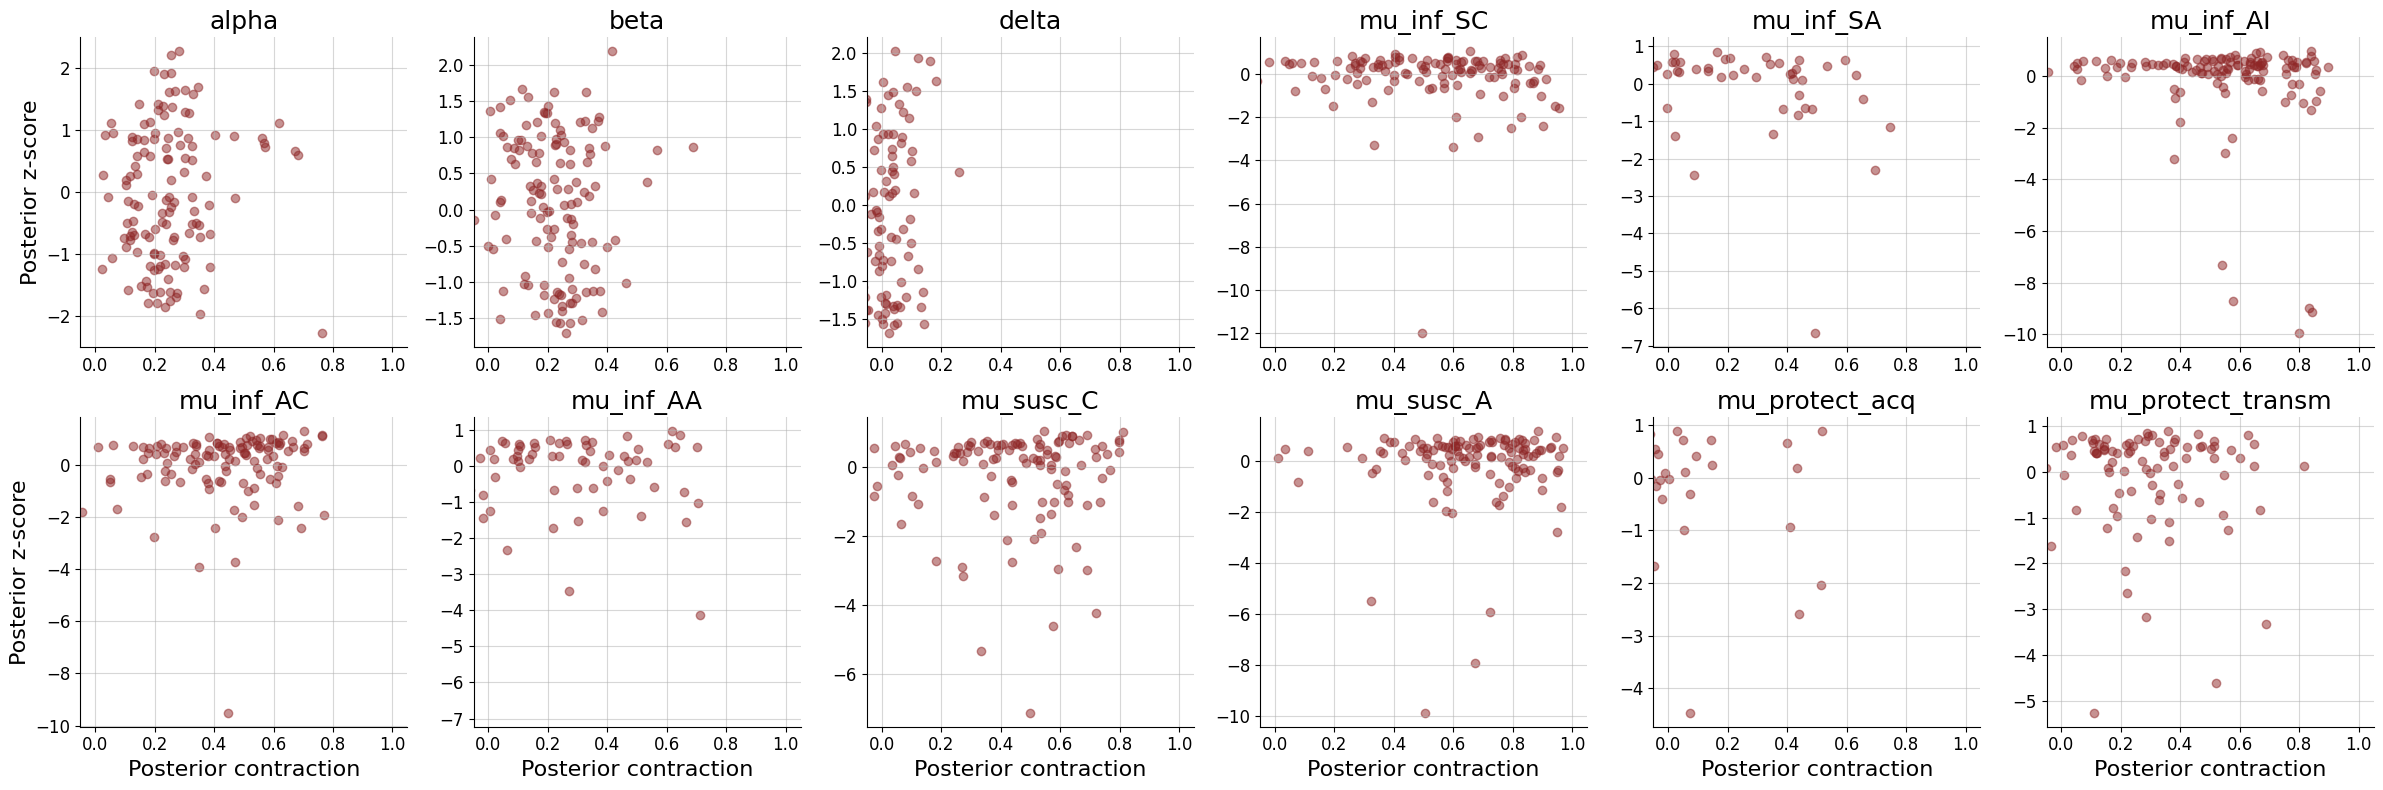

In [24]:
bf.diagnostics.plot_z_score_contraction(posterior_samples, prior_draws, param_names=param_names);

In [25]:
posterior_samples_reshaped = posterior_samples.reshape(posterior_samples.shape[1], posterior_samples.shape[0], posterior_samples.shape[2])

In [26]:
ecp_bootstrap, alpha = get_tarp_coverage(posterior_samples_reshaped, prior_draws, references='random', #posterior_samples_reshaped[0, :, :]
                                         metric='euclidean', norm=True, bootstrap=True)

100%|██████████| 100/100 [00:00<00:00, 1508.32it/s]


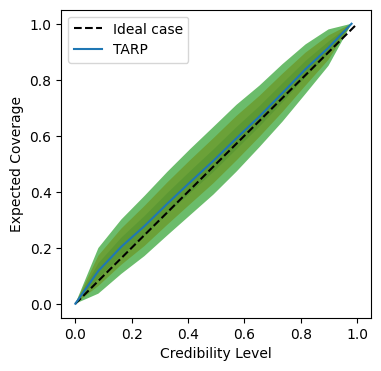

In [27]:
k_sigma = [1, 2, 3]

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot([0, 1], [0, 1], ls='--', color='k', label="Ideal case")
ax.plot(alpha, ecp_bootstrap.mean(axis=0), label='TARP')
for k in k_sigma:
    ax.fill_between(alpha, 
                    ecp_bootstrap.mean(axis=0) - k * ecp_bootstrap.std(axis=0), 
                    ecp_bootstrap.mean(axis=0) + k * ecp_bootstrap.std(axis=0), 
                    alpha = 0.7)
ax.legend()
ax.set_ylabel("Expected Coverage")
ax.set_xlabel("Credibility Level")
plt.show()

# Test on synthetic data

In [28]:
np.random.seed(0)
test_data = generative_model(1)
true_params = test_data['prior_draws'].flatten()
random_sim = bayes_simulator_random(true_params[np.newaxis])
true_params

array([ 0.05488135,  7.15189366,  0.61658026,  0.10348504,  3.79447242,
        0.43053612,  7.17013475,  3.54705801,  0.60297681, 12.74578691,
        2.94707135,  1.62305821])

In [29]:
# get posterior samples and simulate
if not os.path.exists(checkpoint_path+'/posterior_sim.npy'):
    test_posterior_samples = amortizer.sample(trainer.configurator(test_data), n_samples=100)
    test_posterior_samples = test_posterior_samples * prior_std + prior_mean
    
    # simulate the data
    #posterior_sim = bayes_simulator(test_posterior_samples)['sim_data']
    #np.save(checkpoint_path+'/posterior_sim.npy', posterior_sim)
else:
    test_posterior_samples = amortizer.sample(trainer.configurator(test_data), n_samples=100)
    test_posterior_samples = test_posterior_samples * prior_std + prior_mean
    
    posterior_sim = np.load(checkpoint_path+'/posterior_sim.npy')

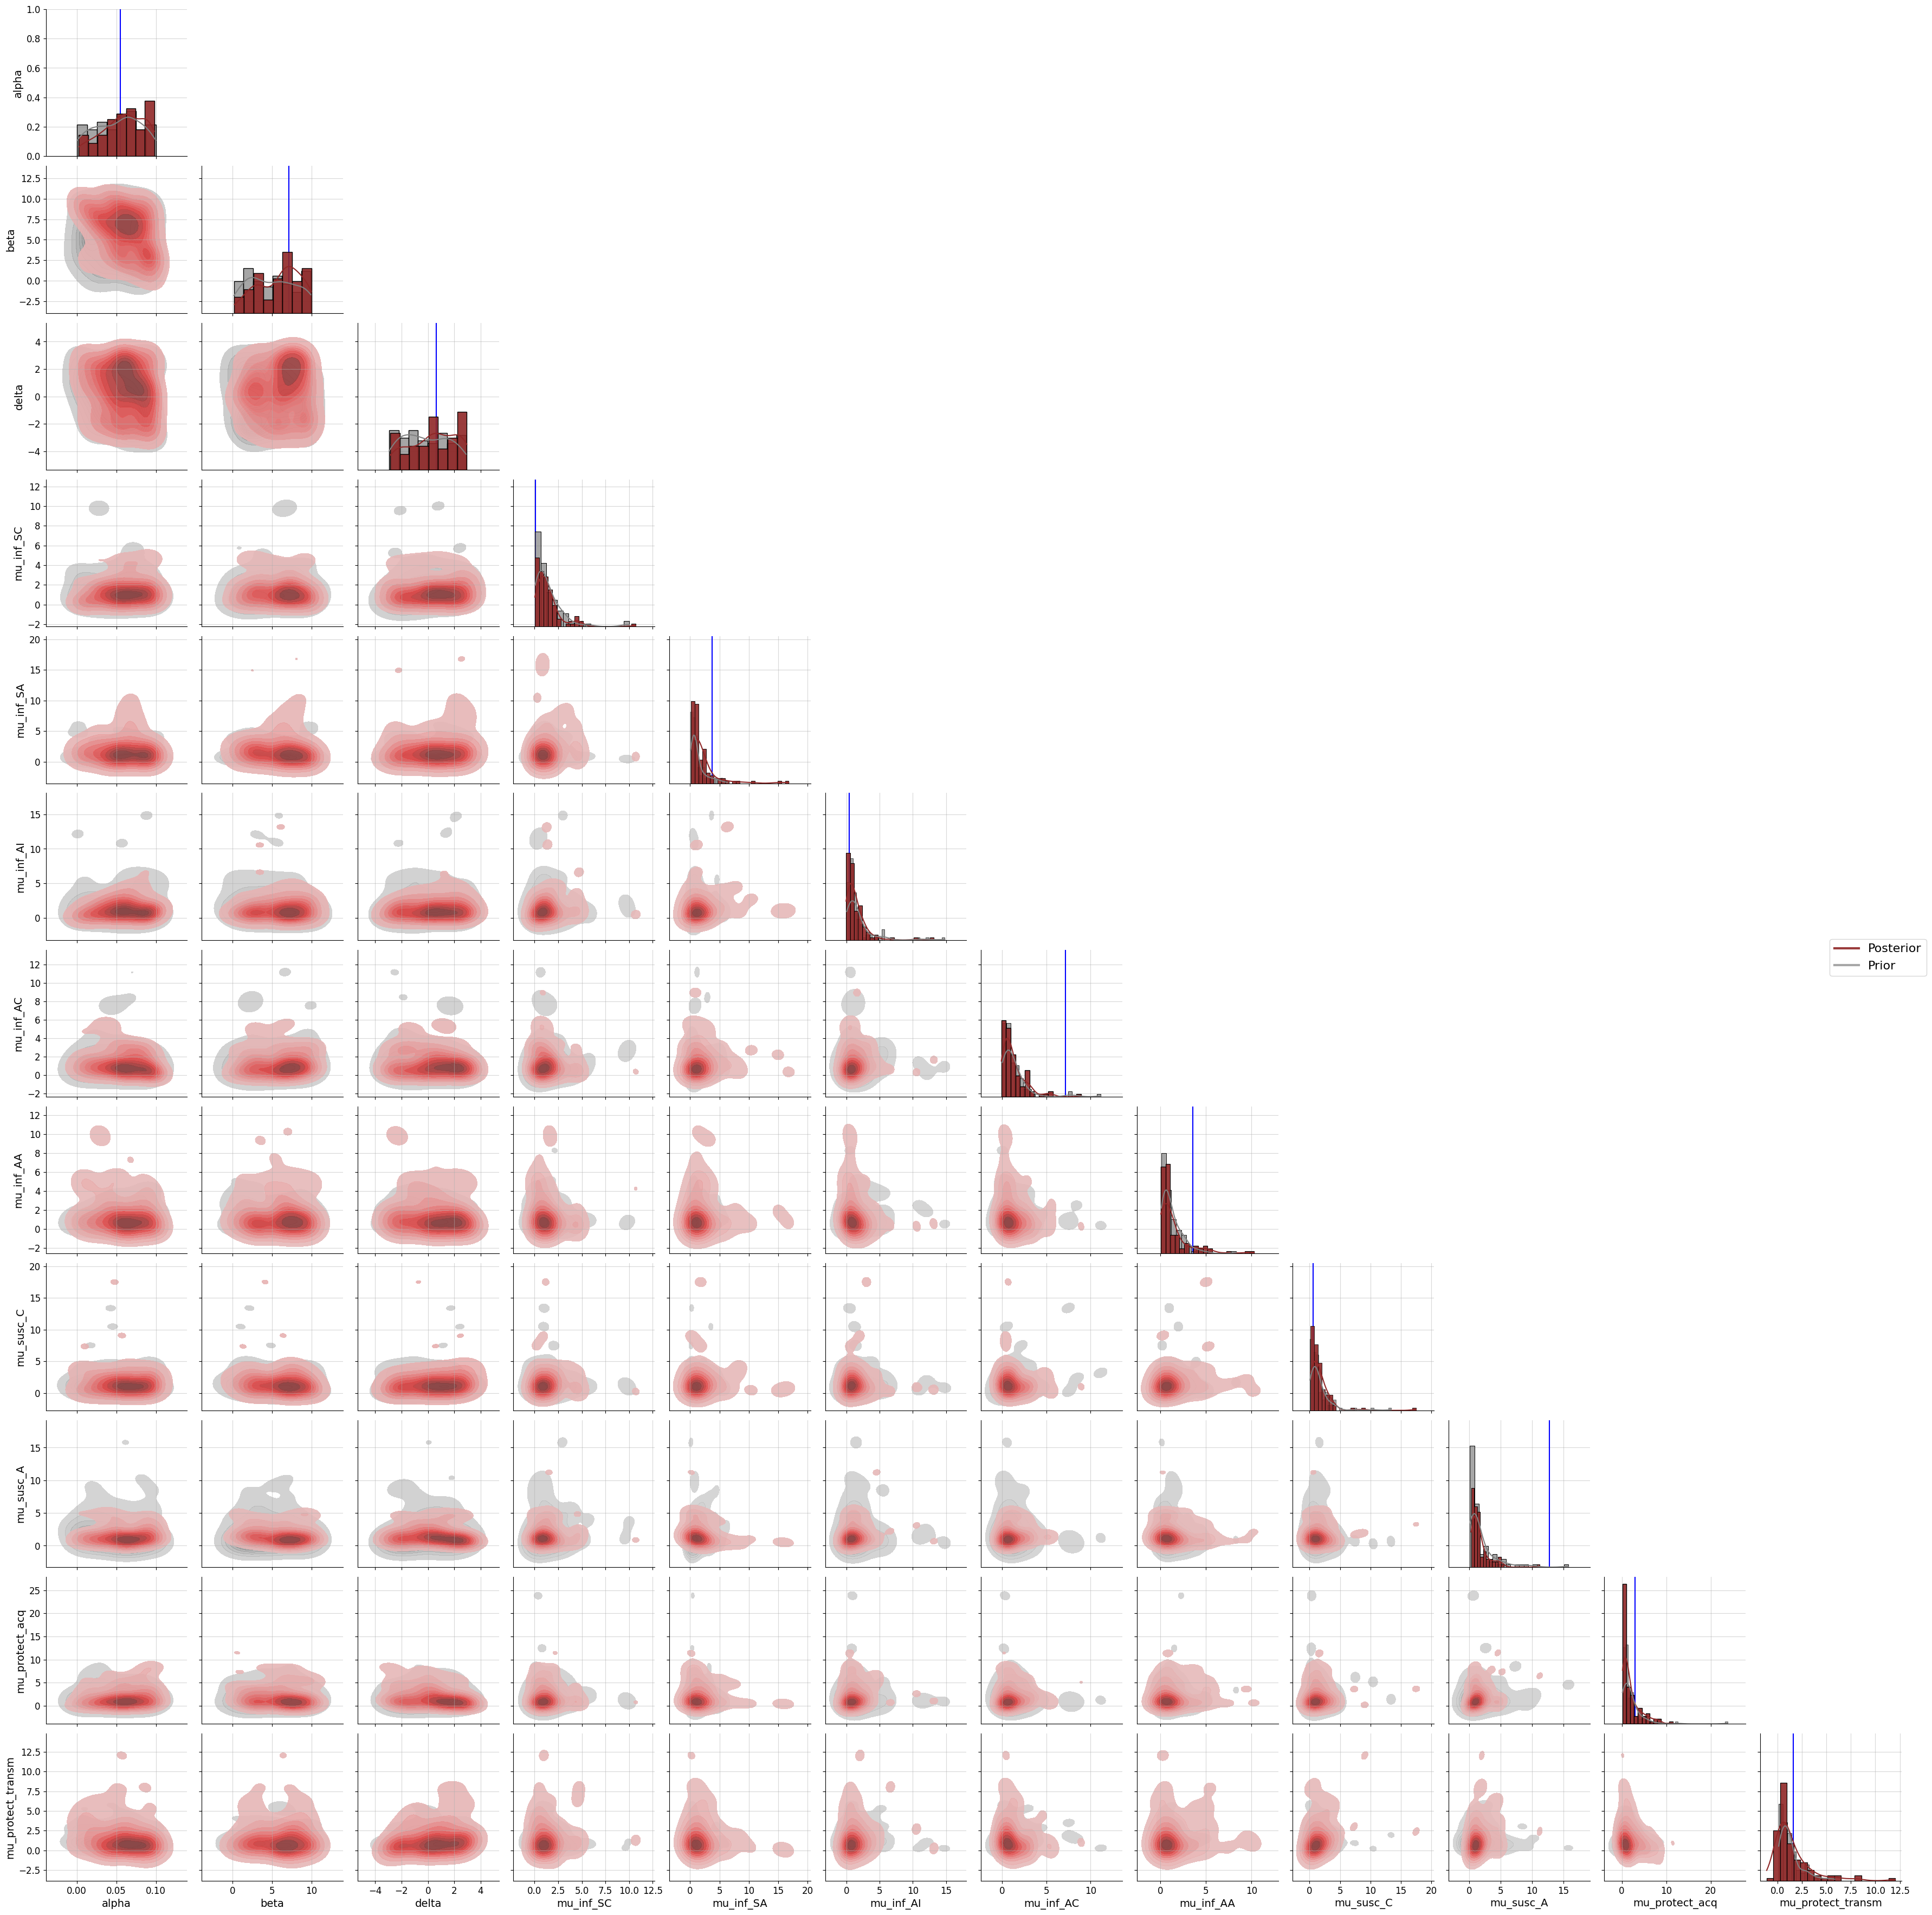

In [30]:
fig = bf.diagnostics.plot_posterior_2d(posterior_draws=test_posterior_samples,
                                       prior=prior, 
                                       param_names=param_names)
# from figure get axis
ax = fig.get_axes()
for i, a in enumerate(ax):
    # plot only on the diagonal
    if i == i // len(param_names) * (len(param_names) + 1):
        a.axvline(true_params[i // len(param_names)], color='b', label='True parameter')

In [31]:
rand_posterior_samples = amortizer.sample(trainer.configurator(random_sim), n_samples=100)
rand_posterior_samples = rand_posterior_samples * prior_std + prior_mean

In [ ]:
fig = bf.diagnostics.plot_posterior_2d(posterior_draws=rand_posterior_samples,
                                       prior=prior, 
                                       param_names=param_names)
# from figure get axis
ax = fig.get_axes()
for i, a in enumerate(ax):
    # plot only on the diagonal
    if i == i // len(param_names) * (len(param_names) + 1):
        a.axvline(true_params[i // len(param_names)], color='b', label='True parameter')

In [ ]:
test_sims = trainer.configurator(valid_data)
posterior_samples = amortizer.sample(test_sims, n_samples=100)
posterior_samples = posterior_samples * prior_std + prior_mean
prior_draws = test_sims["parameters"] * prior_std + prior_mean

test_sims_rand = trainer.configurator(valid_data_rand)
posterior_samples_rand = amortizer.sample(test_sims_rand, n_samples=100)
posterior_samples_rand = posterior_samples_rand * prior_std + prior_mean
prior_draws_rand = test_sims_rand["parameters"] * prior_std + prior_mean

In [ ]:
bf.diagnostics.plot_recovery(posterior_samples, prior_draws, param_names=param_names);

In [ ]:
bf.diagnostics.plot_recovery(posterior_samples_rand, prior_draws_rand, param_names=param_names);